In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import warnings

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist


SEED = 125
np.random.seed(SEED)

torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')\

if DEVICE is not None:
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = None

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
warnings.filterwarnings('ignore')

print('Torch device:', DEVICE,
      '(cuda)' if DEVICE.type == 'cuda' else '(cpu)',
      'GPU:', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'n/a')

Torch device: cpu (cpu) GPU: n/a


In [2]:
DATA_ROOT = Path(r"C:\Users\plasm\PycharmProjects\ai-lab-gene-expression\data")

SMART = DATA_ROOT / 'SmartSeq'
DROP = DATA_ROOT / 'DropSeq'
OUT_DIR = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True)

assert SMART.exists() and DROP.exists(), f'Data folders not found, check DATA_ROOT'

def load_expr(path):
    df = pd.read_csv(path, sep=r'\s+', engine='python', index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    return df

print(f'OK, using DATA_ROOT = {DATA_ROOT}')

OK, using DATA_ROOT = C:\Users\plasm\PycharmProjects\ai-lab-gene-expression\data


In [3]:
matrices = {}

matrices[('SmartSeq', 'MCF7', 'unfiltered')]  = load_expr(SMART / 'MCF7_SmartS_Unfiltered_Data.txt')
matrices[('SmartSeq', 'MCF7', 'filtered')]    = load_expr(SMART / 'MCF7_SmartS_Filtered_Data.txt')
matrices[('SmartSeq', 'MCF7', 'normalised')]  = load_expr(SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt')
matrices[('SmartSeq', 'HCC1806', 'unfiltered')] = load_expr(SMART / 'HCC1806_SmartS_Unfiltered_Data.txt')
matrices[('SmartSeq', 'HCC1806', 'filtered')]   = load_expr(SMART / 'HCC1806_SmartS_Filtered_Data.txt')
matrices[('SmartSeq', 'HCC1806', 'normalised')] = load_expr(SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt')

matrices[('DropSeq', 'MCF7', 'normalised')]    = load_expr(DROP / 'MCF7_Filtered_Normalised_3000_Data_train.txt')
matrices[('DropSeq', 'HCC1806', 'normalised')] = load_expr(DROP / 'HCC1806_Filtered_Normalised_3000_Data_train.txt')

summary_rows = []
for (tech, line, stage), df in matrices.items():
    summary_rows.append({'technology': tech, 'cell_line': line, 'stage': stage,
                         'n_genes': df.shape[0], 'n_cells': df.shape[1]})
summary_df = pd.DataFrame(summary_rows).sort_values(['technology', 'cell_line', 'stage']).reset_index(drop=True)
summary_df

,technology,cell_line,stage,n_genes,n_cells
0,DropSeq,HCC1806,normalised,3000,14682
1,DropSeq,MCF7,normalised,3000,21626
2,SmartSeq,HCC1806,filtered,19503,227
3,SmartSeq,HCC1806,normalised,3000,182
4,SmartSeq,HCC1806,unfiltered,23396,243
5,SmartSeq,MCF7,filtered,18945,313
6,SmartSeq,MCF7,normalised,3000,250
7,SmartSeq,MCF7,unfiltered,22934,383


In [4]:
def extract_label(cell_name: str):
    s = cell_name.lower()
    if '_hypoxia' in s or '_hypo_' in s or s.endswith('_hypo'):
        return 'Hypo'
    if '_normoxia' in s or '_norm_' in s or s.endswith('_norm'):
        return 'Norm'
    return None

meta_rows = []
for (tech, line, stage), df in matrices.items():
    for cell in df.columns:
        meta_rows.append({
            'cell_id': cell,
            'technology': tech,
            'cell_line': line,
            'stage': stage,
            'condition': extract_label(cell),
        })
meta = pd.DataFrame(meta_rows)

labels_by_cell = meta.drop_duplicates('cell_id').set_index('cell_id')['condition']

meta_smart_mcf7 = pd.read_csv(SMART / 'MCF7_SmartS_MetaData.tsv', sep='\t')
meta_smart_hcc  = pd.read_csv(SMART / 'HCC1806_SmartS_MetaData.tsv', sep='\t')
for m in (meta_smart_mcf7, meta_smart_hcc):
    m['Filename'] = m['Filename'].astype(str).str.replace('"', '', regex=False)

counts = (meta[meta['stage'] == 'normalised']
          .groupby(['technology', 'cell_line', 'condition'])
          .size().unstack(fill_value=0))
counts

condition             Hypo   Norm
technology cell_line             
DropSeq    HCC1806    8899   5783
           MCF7       8921  12705
SmartSeq   HCC1806      97     85
           MCF7        124    126

In [5]:
def quick_stats(df):
    vals = df.values.astype(float)
    return pd.Series({
        'n_genes': df.shape[0],
        'n_cells': df.shape[1],
        'dtype': str(df.dtypes.unique().tolist()),
        'min': vals.min(),
        'max': vals.max(),
        'mean': vals.mean(),
        'median': float(np.median(vals)),
        'std': vals.std(),
        'frac_zero': (vals == 0).mean(),
    })

stats_df = pd.DataFrame({f'{t}/{l}/{s}': quick_stats(df) for (t, l, s), df in matrices.items()}).T
stats_df

,n_genes,n_cells,dtype,min,max,mean,median,std,frac_zero
SmartSeq/MCF7/unfiltered,22934,383,[dtype('int64')],0.0,190556.0,43.368444,0.0,509.964431,0.602153
SmartSeq/MCF7/filtered,18945,313,[dtype('int64')],0.0,190556.0,61.114583,1.0,597.129987,0.471576
SmartSeq/MCF7/normalised,3000,250,[dtype('int64')],0.0,107556.0,115.900049,0.0,1024.443801,0.636221
SmartSeq/HCC1806/unfiltered,23396,243,[dtype('int64')],0.0,210944.0,86.010698,0.0,579.986467,0.558456
SmartSeq/HCC1806/filtered,19503,227,[dtype('int64')],0.0,210944.0,107.439569,3.0,644.41004,0.452056
SmartSeq/HCC1806/normalised,3000,182,[dtype('int64')],0.0,109881.0,167.526872,0.0,1046.499482,0.706535
DropSeq/MCF7/normalised,3000,21626,[dtype('int64')],0.0,175.0,0.035819,0.0,0.303044,0.975294
DropSeq/HCC1806/normalised,3000,14682,[dtype('int64')],0.0,110.0,0.0355,0.0,0.28424,0.976376


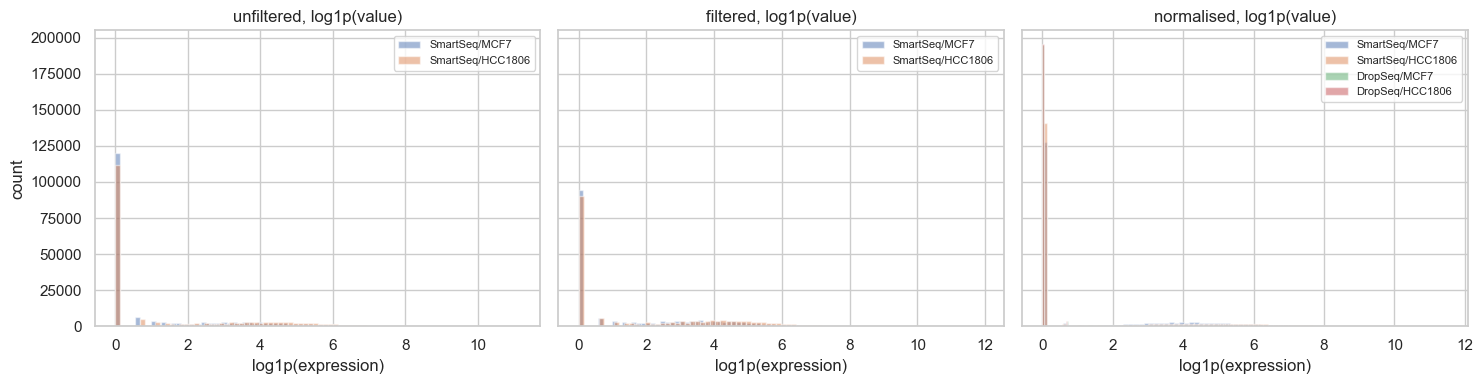

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, stage in zip(axes, ['unfiltered', 'filtered', 'normalised']):
    for (tech, line, s), df in matrices.items():
        if s != stage:
            continue
        sample = df.values.flatten()
        if sample.size > 200_000:
            sample = np.random.default_rng(SEED).choice(sample, 200_000, replace=False)
        ax.hist(np.log1p(sample), bins=80, alpha=0.5, label=f'{tech}/{line}')
    ax.set_title(f'{stage}, log1p(value)')
    ax.set_xlabel('log1p(expression)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('count')
plt.tight_layout()
plt.show()

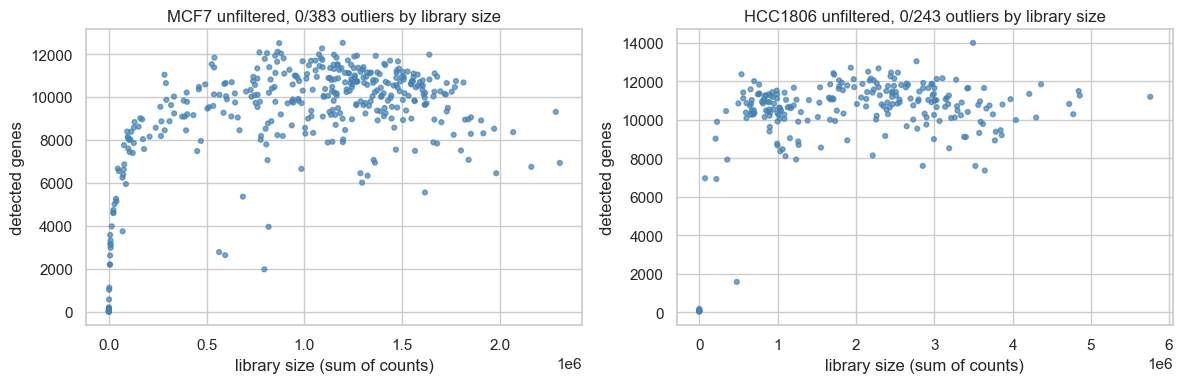

In [7]:
def iqr_flags(series: pd.Series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lo) | (series > hi), (lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, df) in zip(axes, [('MCF7 unfiltered', matrices[('SmartSeq', 'MCF7', 'unfiltered')]),
                                    ('HCC1806 unfiltered', matrices[('SmartSeq', 'HCC1806', 'unfiltered')])]):
    lib = df.sum(axis=0)
    detected = (df > 0).sum(axis=0)
    flagged, bounds = iqr_flags(lib)
    ax.scatter(lib, detected, c=np.where(flagged, 'red', 'steelblue'), s=12, alpha=0.7)
    ax.set_xlabel('library size (sum of counts)')
    ax.set_ylabel('detected genes')
    ax.set_title(f'{label}, {flagged.sum()}/{len(flagged)} outliers by library size')
plt.tight_layout()
plt.show()

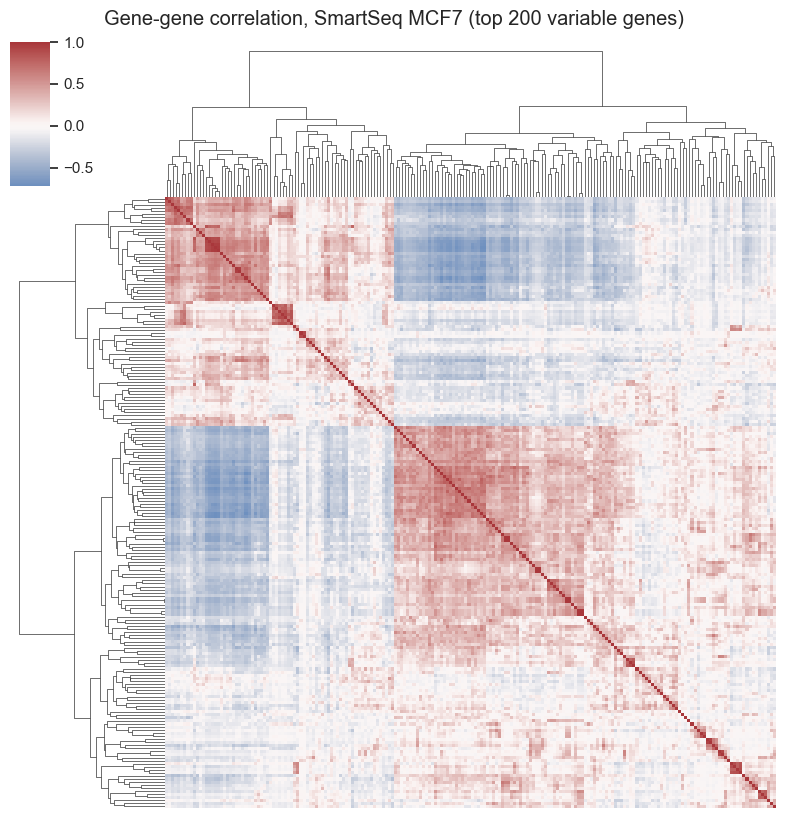

In [8]:
def prep_matrix(df):
    X = df.T.astype(float)
    return X

X_mcf7 = prep_matrix(matrices[('SmartSeq', 'MCF7', 'normalised')])
var_genes = X_mcf7.var(axis=0).nlargest(200).index
corr = X_mcf7[var_genes].corr()
g = sns.clustermap(corr, cmap='vlag', center=0, figsize=(8, 8),
                   xticklabels=False, yticklabels=False)
g.fig.suptitle('Gene-gene correlation, SmartSeq MCF7 (top 200 variable genes)', y=1.02)
plt.show()

In [9]:
matrices_log = {key: np.log1p(df.astype('float32')) for key, df in matrices.items()}

ranges = pd.DataFrame({
      f'{t}/{l}/{s}': {
          'shape':     str(matrices[(t, l, s)].shape),
          'raw_max':   float(matrices[(t, l, s)].values.max()),
          'log1p_max': float(matrices_log[(t, l, s)].values.max()),
      } for (t, l, s) in matrices
})
ranges


,SmartSeq/MCF7/unfiltered,SmartSeq/MCF7/filtered,SmartSeq/MCF7/normalised,SmartSeq/HCC1806/unfiltered,SmartSeq/HCC1806/filtered,SmartSeq/HCC1806/normalised,DropSeq/MCF7/normalised,DropSeq/HCC1806/normalised
shape,"(22934, 383)","(18945, 313)","(3000, 250)","(23396, 243)","(19503, 227)","(3000, 182)","(3000, 21626)","(3000, 14682)"
raw_max,190556.0,190556.0,107556.0,210944.0,210944.0,109881.0,175.0,110.0
log1p_max,12.157706,12.157706,11.585776,12.259353,12.259353,11.607162,5.170484,4.70953


SmartSeq: 1208 genes shared between MCF7 and HCC1806, 432 cells
DropSeq: 834 genes shared between MCF7 and HCC1806, 36308 cells


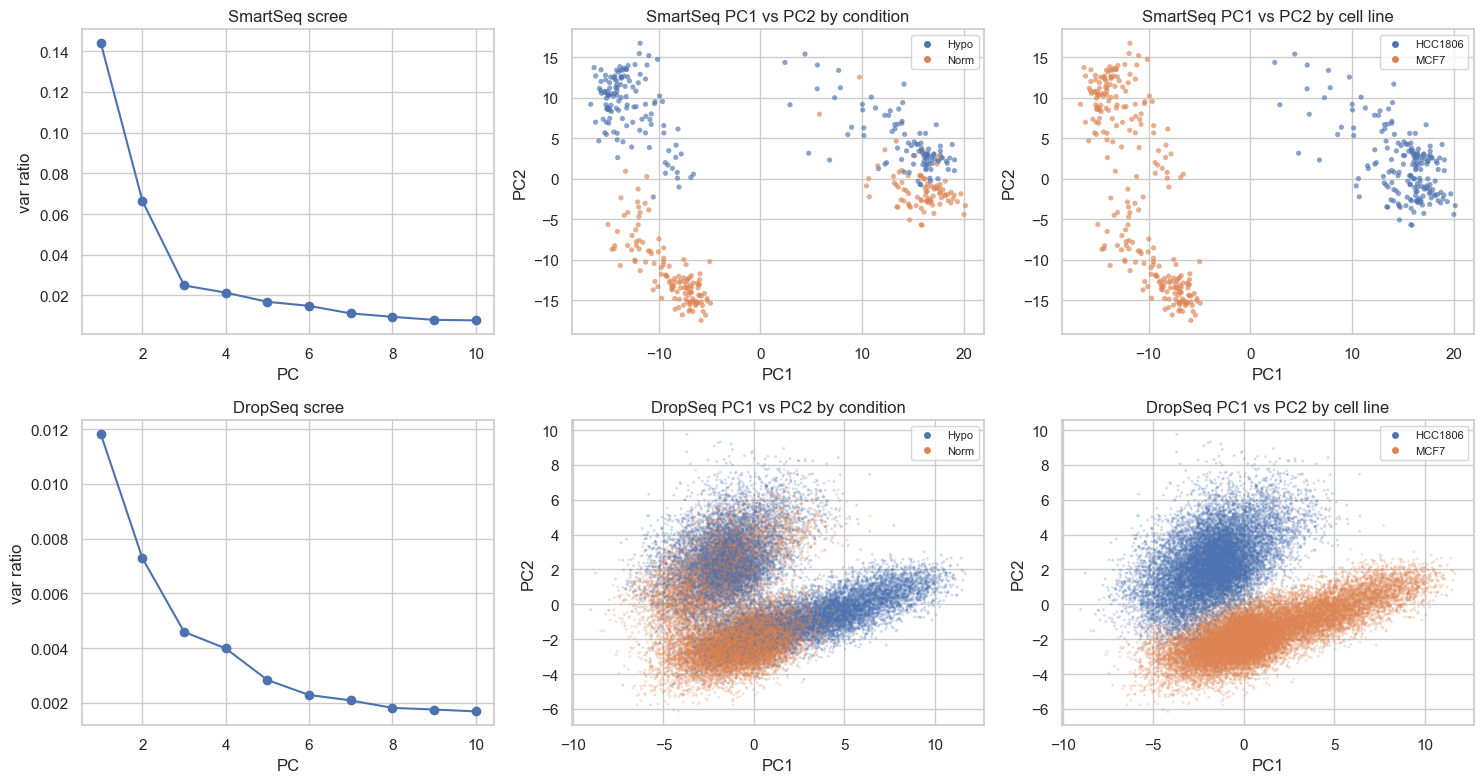

Shared genes across all 4 normalised subsets: 70


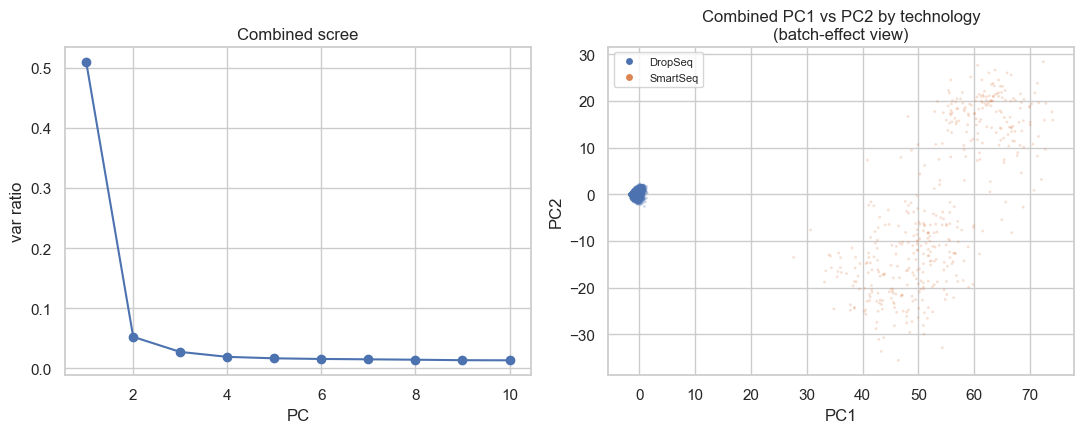

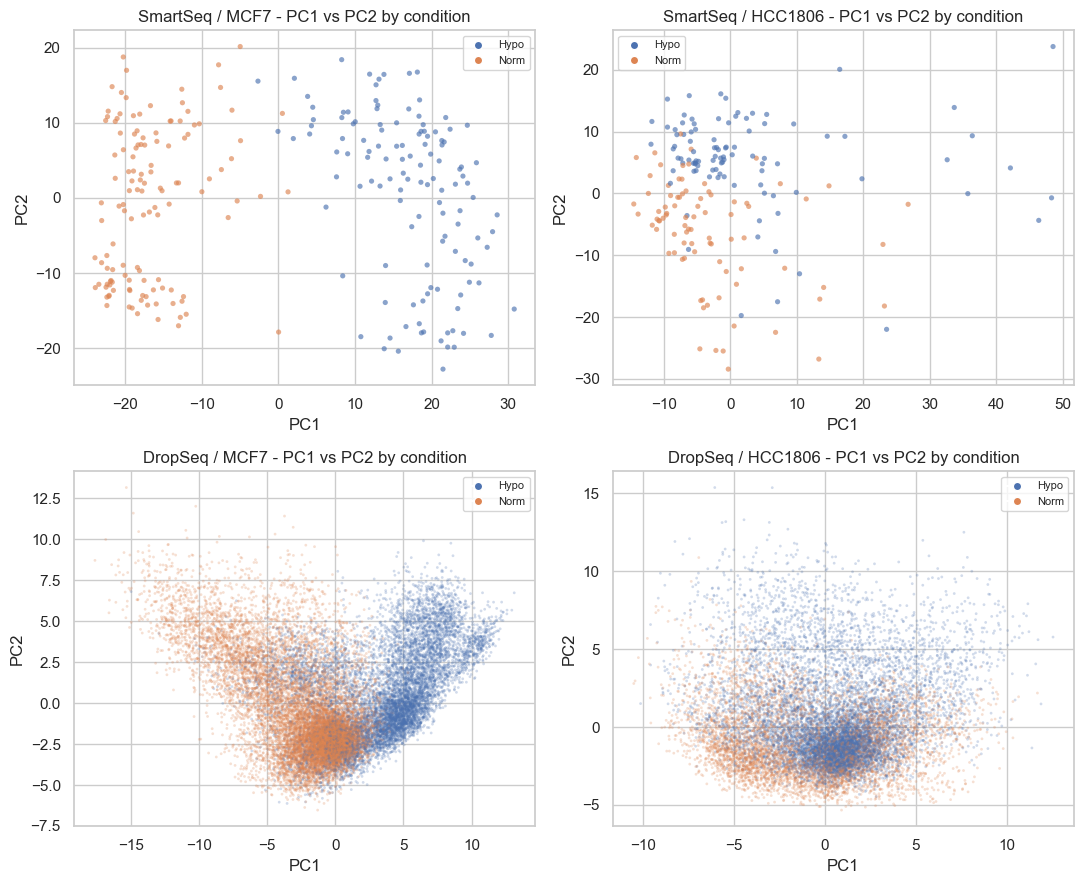

In [10]:
def _stack_tech(tech, mats):
    dfs   = {line: mats[(tech, line, 'normalised')] for line in ('MCF7', 'HCC1806')}
    genes = sorted(set.intersection(*(set(df.index) for df in dfs.values())))

    pieces = []
    for line, df in dfs.items():
        cells_x_genes = df.loc[genes].T.copy()
        cells_x_genes['cell_line']  = line
        cells_x_genes['technology'] = tech
        cells_x_genes['cell_id']    = cells_x_genes.index
        pieces.append(cells_x_genes)
    out = pd.concat(pieces, ignore_index=True)
    out['condition'] = labels_by_cell.reindex(out['cell_id']).values
    return out, genes

def _fit_pca(X, n_components=10):
    Xs  = StandardScaler().fit_transform(np.asarray(X, dtype=float))
    pca = PCA(n_components=n_components, random_state=SEED).fit(Xs)
    return Xs, pca, pca.transform(Xs)

def _scatter_mixed(ax, x, y, labels, s=8, alpha=0.5, seed=SEED):
    """Scatter with shuffled z-order so neither group is consistently on top."""
    from matplotlib.lines import Line2D
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(x))
    x = np.asarray(x)[order]
    y = np.asarray(y)[order]
    labels = pd.Series(labels).fillna('NaN').astype(str).values[order]
    uniq = sorted(set(labels))
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    cmap = {l: cycle[i % len(cycle)] for i, l in enumerate(uniq)}
    ax.scatter(x, y, c=[cmap[l] for l in labels],
               s=s, alpha=alpha, edgecolors='none', linewidths=0)
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap[l],
                      markersize=6, label=l) for l in uniq]
    ax.legend(handles=handles, fontsize=8)

# --- Per-technology PCA on the within-tech intersection of genes (log1p) ---
per_tech_pca = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, tech in enumerate(['SmartSeq', 'DropSeq']):
    df_tech, gene_cols = _stack_tech(tech, matrices_log)
    Xs_tech, pca_tech, emb_tech = _fit_pca(df_tech[gene_cols].values)
    per_tech_pca[tech] = (df_tech, gene_cols, Xs_tech, pca_tech, emb_tech)
    print(f'{tech}: {len(gene_cols)} genes shared between MCF7 and HCC1806, {len(df_tech)} cells')

    s, alpha = (14, 0.65) if tech == 'SmartSeq' else (4, 0.25)
    ax_scree, ax_cond, ax_line = axes[row]
    ax_scree.plot(np.arange(1, 11), pca_tech.explained_variance_ratio_, marker='o')
    ax_scree.set_title(f'{tech} scree'); ax_scree.set_xlabel('PC'); ax_scree.set_ylabel('var ratio')

    _scatter_mixed(ax_cond, emb_tech[:, 0], emb_tech[:, 1],
                   df_tech['condition'].values, s=s, alpha=alpha)
    ax_cond.set_title(f'{tech} PC1 vs PC2 by condition')
    ax_cond.set_xlabel('PC1'); ax_cond.set_ylabel('PC2')

    _scatter_mixed(ax_line, emb_tech[:, 0], emb_tech[:, 1],
                   df_tech['cell_line'].values, s=s, alpha=alpha)
    ax_line.set_title(f'{tech} PC1 vs PC2 by cell line')
    ax_line.set_xlabel('PC1'); ax_line.set_ylabel('PC2')
plt.tight_layout(); plt.show()

# --- Combined PCA on shared genes across all 4 subsets (log1p) - batch-effect view ---
normalised_subsets_log = {(t, l): matrices_log[(t, l, 'normalised')]
                        for t in ('SmartSeq', 'DropSeq') for l in ('MCF7', 'HCC1806')}
shared_genes = sorted(set.intersection(*(set(df.index) for df in normalised_subsets_log.values())))
print(f'Shared genes across all 4 normalised subsets: {len(shared_genes)}')

pieces = []
for (tech, line), df in normalised_subsets_log.items():
    sub = df.loc[shared_genes].T.copy()
    sub['technology'] = tech
    sub['cell_line']  = line
    sub['cell_id']    = sub.index
    pieces.append(sub)
combined = pd.concat(pieces, ignore_index=True)
combined['condition'] = labels_by_cell.reindex(combined['cell_id']).values

Xs, pca_combined, emb_combined = _fit_pca(combined[shared_genes].values)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(np.arange(1, 11), pca_combined.explained_variance_ratio_, marker='o')
axes[0].set_title('Combined scree'); axes[0].set_xlabel('PC'); axes[0].set_ylabel('var ratio')
_scatter_mixed(axes[1], emb_combined[:, 0], emb_combined[:, 1],
               combined['technology'].values, s=4, alpha=0.25)
axes[1].set_title('Combined PC1 vs PC2 by technology\n(batch-effect view)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()

# --- Per-(tech, cell-line) PCA ---
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, tech in enumerate(['SmartSeq', 'DropSeq']):
    for col, line in enumerate(['MCF7', 'HCC1806']):
        df = matrices_log[(tech, line, 'normalised')].T
        Xs_, _, emb_ = _fit_pca(df.values)
        cond = labels_by_cell.reindex(df.index).values
        s, alpha = (14, 0.65) if tech == 'SmartSeq' else (4, 0.25)
        _scatter_mixed(axes[row, col], emb_[:, 0], emb_[:, 1], cond, s=s, alpha=alpha)
        axes[row, col].set_title(f'{tech} / {line} - PC1 vs PC2 by condition')
        axes[row, col].set_xlabel('PC1'); axes[row, col].set_ylabel('PC2')
plt.tight_layout(); plt.show()


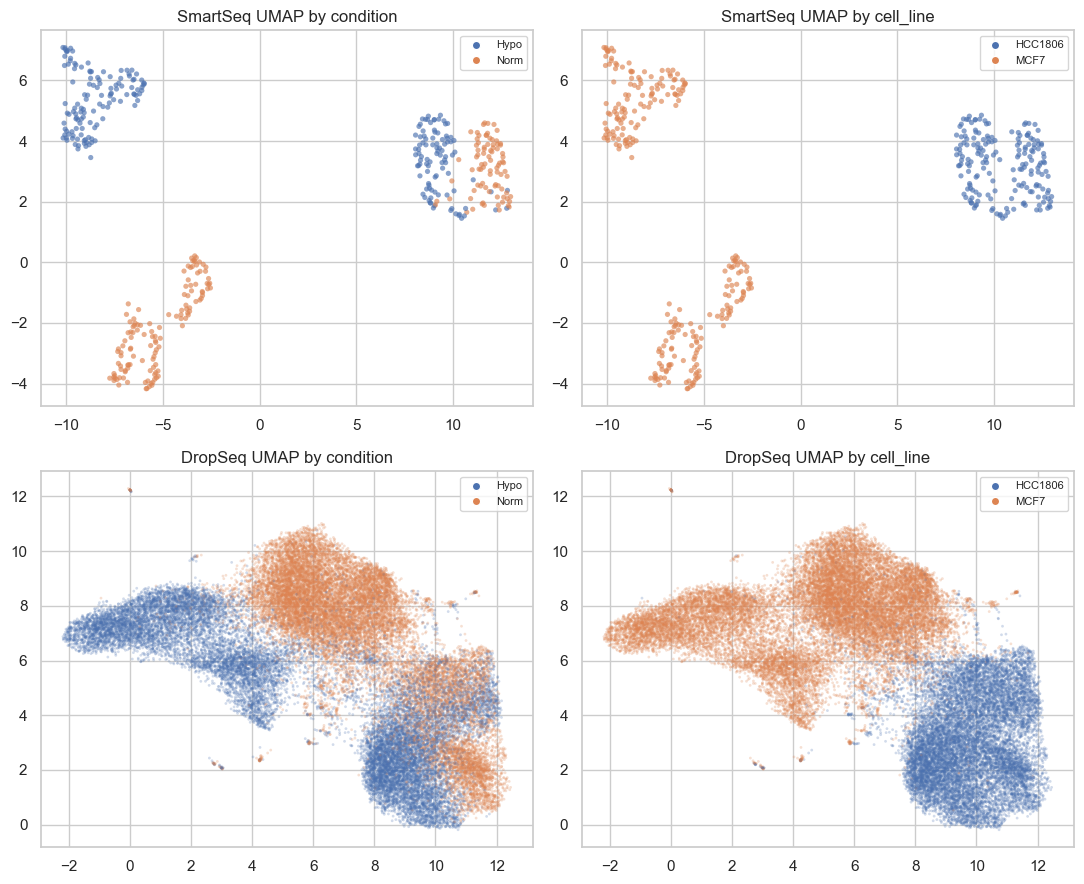

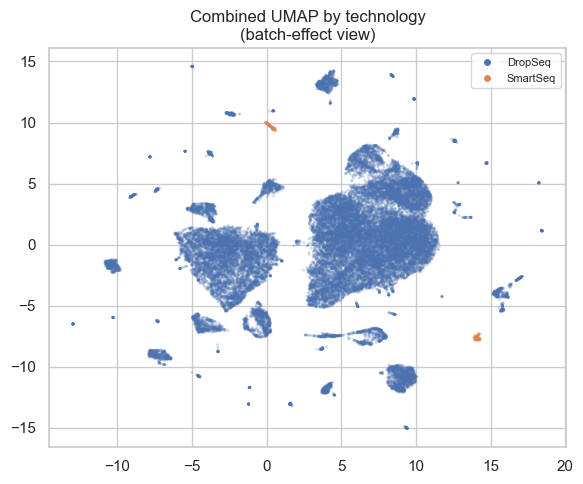

In [11]:
def _umap_on(Xs_in, n_pcs=30):
    k = min(n_pcs, Xs_in.shape[1] - 1)
    emb_pcs = PCA(n_components=k, random_state=SEED).fit_transform(Xs_in)
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.3)
    return np.asarray(reducer.fit_transform(emb_pcs))

# Per-tech UMAPs - biology view
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, tech in enumerate(['SmartSeq', 'DropSeq']):
    df_tech, _, Xs_tech, _, _ = per_tech_pca[tech]
    u = _umap_on(Xs_tech)
    s, alpha = (14, 0.65) if tech == 'SmartSeq' else (4, 0.25)
    for ax, colour_by in zip(axes[row], ['condition', 'cell_line']):
        _scatter_mixed(ax, u[:, 0], u[:, 1], df_tech[colour_by].values, s=s, alpha=alpha)
        ax.set_title(f'{tech} UMAP by {colour_by}')
plt.tight_layout(); plt.show()

# Combined UMAP - batch-effect view
u_all = _umap_on(Xs)
fig, ax = plt.subplots(figsize=(6, 5))
_scatter_mixed(ax, u_all[:, 0], u_all[:, 1], combined['technology'].values, s=4, alpha=0.25)
ax.set_title('Combined UMAP by technology\n(batch-effect view)')
plt.tight_layout(); plt.show()


In [12]:
# --- AE data prep: per-tech train/val split + per-gene standardisation ---
# Inputs come from matrices_log via per_tech_pca[tech] (within-tech intersection
# of variable genes - SmartSeq=1208, DropSeq=834 on my test). Stratify the split on
# (cell_line, condition) so val keeps all four strata. Scaler is fit on train
# only to avoid leaking val statistics into the AE input.
from sklearn.model_selection import train_test_split

ae_data = {}
for tech in ('SmartSeq', 'DropSeq'):
    df_tech, gene_cols, _, _, _ = per_tech_pca[tech]
    X = df_tech[gene_cols].values.astype('float32')

    strat = (df_tech['cell_line'].astype(str) + '|' +
             df_tech['condition'].fillna('NaN').astype(str)).values

    idx_tr, idx_va = train_test_split(
        np.arange(len(X)), test_size=0.2, random_state=SEED, stratify=strat
    )

    scaler = StandardScaler().fit(X[idx_tr])
    Xs_full = scaler.transform(X).astype('float32')

    ae_data[tech] = {
        'df_tech':  df_tech,
        'gene_cols': gene_cols,
        'scaler':   scaler,
        'idx_tr':   idx_tr,
        'idx_va':   idx_va,
        'Xs_full':  Xs_full,
        'Xtr':      Xs_full[idx_tr],
        'Xva':      Xs_full[idx_va],
    }
    print(f'{tech}: n_in={X.shape[1]} genes, train={len(idx_tr)} cells, val={len(idx_va)} cells')


SmartSeq: n_in=1208 genes, train=345 cells, val=87 cells
DropSeq: n_in=834 genes, train=29046 cells, val=7262 cells


In [13]:
# --- Train one AE and one DAE per technology on the prepared data ---
class AE(nn.Module):
    def __init__(self, n_in, latent=32, hidden=256, depth=1, dropout=0.0, use_bn=False):
        super().__init__()

        def block(in_dim, out_dim):
            layers = [nn.Linear(in_dim, out_dim)]
            if use_bn:
                layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            return layers

        enc_layers, in_dim = [], n_in
        for _ in range(depth):
            enc_layers += block(in_dim, hidden)
            in_dim = hidden
        enc_layers.append(nn.Linear(in_dim, latent))  # linear bottleneck
        self.enc = nn.Sequential(*enc_layers)

        dec_layers, in_dim = [], latent
        for _ in range(depth):
            dec_layers += block(in_dim, hidden)
            in_dim = hidden
        dec_layers.append(nn.Linear(in_dim, n_in))    # linear output
        self.dec = nn.Sequential(*dec_layers)

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

def train_ae(Xtr, Xva, X_full, latent=32, hidden=256, depth=1, dropout=0.0, use_bn=False,
             denoising=False, noise_type='bernoulli', noise_level=0.3,
             epochs=80, batch=256, lr=1e-3, weight_decay=0.0,
             patience=10, seed=SEED, verbose=False):
    """
    Trains an autoencoder. If denoising=True, the input is corrupted on each
    batch and the model must reconstruct the *clean* target:
      - noise_type='bernoulli': zero out a fraction noise_level of values
                                (matches the final-notebook DAE recipe)
      - noise_type='gaussian':  add N(0, noise_level**2) per element
    Validation MSE is always computed on clean inputs so val_loss measures
    latent reconstruction quality, not denoising ability.
    """
    torch.manual_seed(seed)
    device = DEVICE
    n_in = Xtr.shape[1]

    model = AE(n_in, latent=latent, hidden=hidden, depth=depth,
               dropout=dropout, use_bn=use_bn).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=device)
    Xva_t = torch.tensor(Xva, dtype=torch.float32, device=device)
    n = Xtr_t.shape[0]

    history = {'train': [], 'val': []}
    best_val = float('inf')
    best_state = None
    bad_epochs = 0

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        ep_loss = 0.0
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            xb = Xtr_t[idx]

            if denoising:
                if noise_type == 'bernoulli':
                    mask = (torch.rand_like(xb) > noise_level).float()
                    xb_in = xb * mask
                elif noise_type == 'gaussian':
                    xb_in = xb + noise_level * torch.randn_like(xb)
                else:
                    raise ValueError(f'unknown noise_type: {noise_type}')
            else:
                xb_in = xb

            opt.zero_grad(set_to_none=True)
            recon, _ = model(xb_in)
            loss = loss_fn(recon, xb)              # always vs clean target
            loss.backward()
            opt.step()
            ep_loss += float(loss.detach()) * xb.size(0)
        ep_loss /= n

        model.eval()
        with torch.no_grad():
            recon_va, _ = model(Xva_t)             # val on clean
            val_loss = float(loss_fn(recon_va, Xva_t))

        history['train'].append(ep_loss)
        history['val'].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

        if verbose and (ep % 10 == 0 or bad_epochs >= patience):
            print(f'    ep {ep:3d}  train {ep_loss:.4f}  val {val_loss:.4f}')

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        Xfull_t = torch.tensor(X_full, dtype=torch.float32, device=device)
        _, Z = model(Xfull_t)
        Z = Z.detach().cpu().numpy()

    return model, history, Z

# Default-config runs: vanilla AE and DAE (Bernoulli mask, p=0.3) per tech.
ae_models, dae_models = {}, {}
for tech in ('SmartSeq', 'DropSeq'):
    d = ae_data[tech]
    print(f'== {tech} ==')

    print('  AE...')
    model, history, Z = train_ae(d['Xtr'], d['Xva'], d['Xs_full'])
    ae_models[tech] = {'model': model, 'history': history, 'Z': Z,
                       'epochs_trained': len(history['train']),
                       'best_val': min(history['val'])}
    print(f"    {len(history['train'])} epochs, best val MSE = {min(history['val']):.4f}")

    print('  DAE (Bernoulli mask, p=0.3)...')
    model, history, Z = train_ae(d['Xtr'], d['Xva'], d['Xs_full'],
                                 denoising=True, noise_type='bernoulli', noise_level=0.3)
    dae_models[tech] = {'model': model, 'history': history, 'Z': Z,
                        'epochs_trained': len(history['train']),
                        'best_val': min(history['val'])}
    print(f"    {len(history['train'])} epochs, best val MSE = {min(history['val']):.4f}")


== SmartSeq ==
  AE...
    55 epochs, best val MSE = 0.7330
  DAE (Bernoulli mask, p=0.3)...
    40 epochs, best val MSE = 0.7932
== DropSeq ==
  AE...
    80 epochs, best val MSE = 0.7609
  DAE (Bernoulli mask, p=0.3)...
    80 epochs, best val MSE = 0.7669


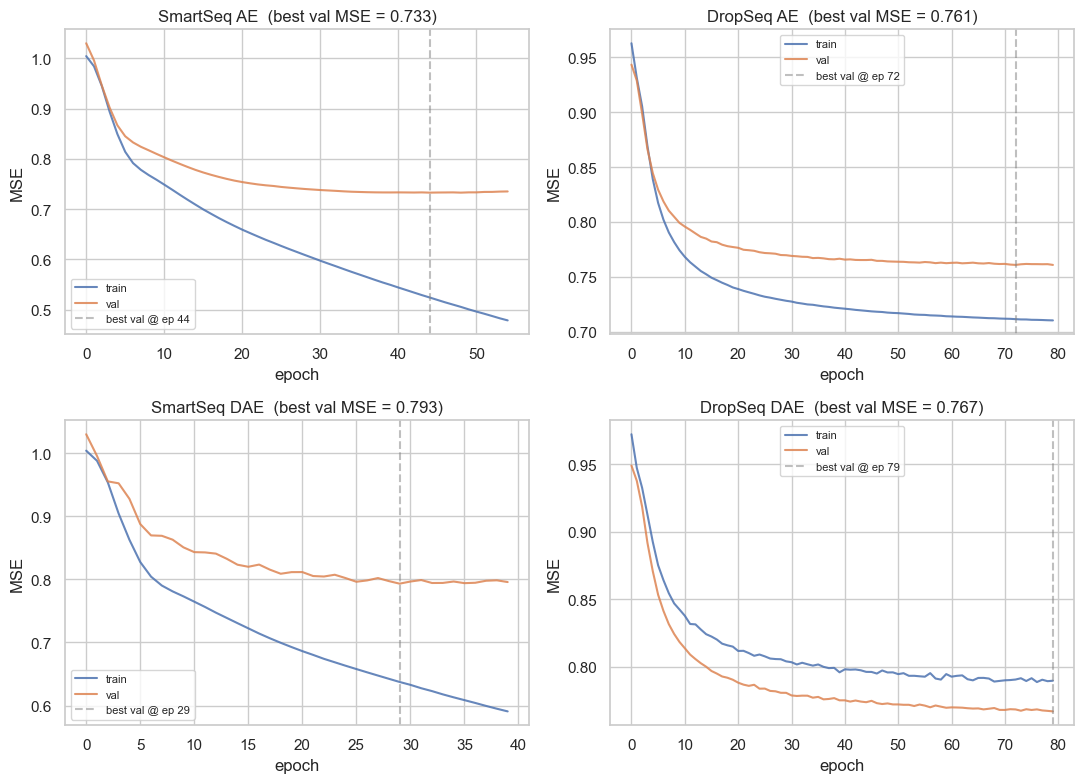

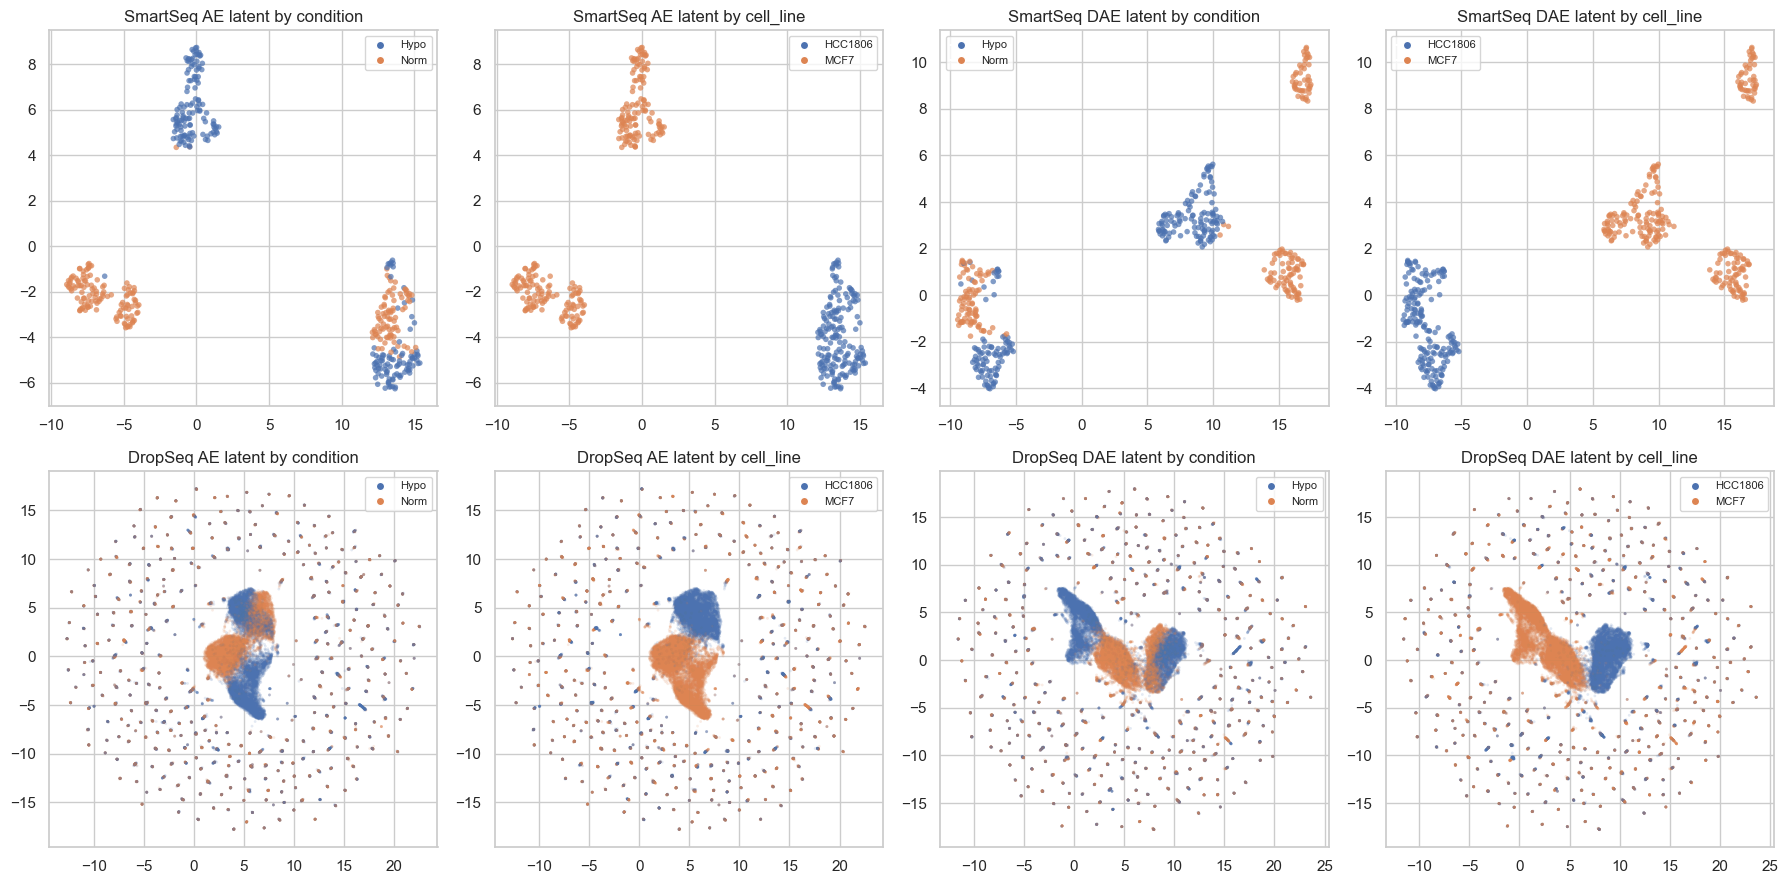

In [14]:
# --- AE + DAE diagnostics: loss curves and latent UMAPs side by side ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, tech in enumerate(['SmartSeq', 'DropSeq']):
    for row, (label, models) in enumerate([('AE', ae_models), ('DAE', dae_models)]):
        ax = axes[row, col]
        h = models[tech]['history']
        ax.plot(h['train'], label='train', alpha=0.85)
        ax.plot(h['val'], label='val', alpha=0.85)
        best_ep = int(np.argmin(h['val']))
        ax.axvline(best_ep, color='grey', linestyle='--', alpha=0.5,
                   label=f'best val @ ep {best_ep}')
        ax.set_title(f'{tech} {label}  (best val MSE = {min(h["val"]):.3f})')
        ax.set_xlabel('epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Latent UMAPs: rows = tech, cols = (AE-cond, AE-line, DAE-cond, DAE-line).
# UMAP is fit once per (tech, label) pair and reused for both colourings.
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for row, tech in enumerate(['SmartSeq', 'DropSeq']):
    s, alpha = (16, 0.7) if tech == 'SmartSeq' else (4, 0.15)
    df_tech = ae_data[tech]['df_tech']
    for pair_idx, (label, models) in enumerate([('AE', ae_models), ('DAE', dae_models)]):
        Z = models[tech]['Z']
        reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.3)
        u = np.asarray(reducer.fit_transform(Z))
        for col_offset, colour_by in enumerate(['condition', 'cell_line']):
            ax = axes[row, pair_idx * 2 + col_offset]
            _scatter_mixed(ax, u[:, 0], u[:, 1], df_tech[colour_by].values, s=s, alpha=alpha)
            ax.set_title(f'{tech} {label} latent by {colour_by}')
plt.tight_layout(); plt.show()


In [15]:
# --- AE reconstruction baselines: trivial + PCA(latent) ---
# After StandardScaler each gene has variance 1, so the trivial "output zeros"
# baseline gives MSE ~= 1. PCA at the same latent dim is the *linear-AE optimum*
# at that compression ratio; if the AE is at or below PCA's MSE it's at least
# learning the linear part. The original notebook's MSE=0.05 was on n_in=70
# features (cross-tech intersection), where PCA(32) is already very good
# because the compression ratio is barely 2x. With our per-tech inputs of
# 1208 / 834 features the ratio is 26-38x and the floor is much higher.
baselines = []
for tech in ('SmartSeq', 'DropSeq'):
    d = ae_data[tech]
    pca32 = PCA(n_components=32, random_state=SEED).fit(d['Xtr'])
    Xva_recon = pca32.inverse_transform(pca32.transform(d['Xva']))
    baselines.append({
        'tech': tech,
        'n_in': d['Xtr'].shape[1],
        'compression': f"{d['Xtr'].shape[1] / 32:.1f}x",
        'trivial val MSE': float(np.mean(d['Xva'] ** 2)),
        'PCA(32) val MSE': float(np.mean((d['Xva'] - Xva_recon) ** 2)),
        'PCA(32) cum var explained': float(pca32.explained_variance_ratio_.sum()),
        'AE val MSE (current)': ae_models[tech]['best_val'],
    })
pd.DataFrame(baselines)


,tech,n_in,compression,trivial val MSE,PCA(32) val MSE,PCA(32) cum var explained,AE val MSE (current)
0,SmartSeq,1208,37.8x,1.039300,0.700332,0.447189,0.733006
1,DropSeq,834,26.1x,1.000777,0.935321,0.076577,0.760888


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

configs = [
    # AE reference points
    dict(name='AE baseline',           denoising=False,                                       latent=32,  hidden=256, depth=1, use_bn=False, epochs=80),
    dict(name='AE latent 64',          denoising=False,                                       latent=64,  hidden=256, depth=1, use_bn=False, epochs=80),
    dict(name='AE latent 128 wide',    denoising=False,                                       latent=128, hidden=512, depth=1, use_bn=False, epochs=80),
    # DAE Bernoulli
    dict(name='DAE bern 0.3',          denoising=True,  noise_type='bernoulli', noise_level=0.3, latent=32,  hidden=256, depth=1, use_bn=False, epochs=80),
    dict(name='DAE bern 0.5',          denoising=True,  noise_type='bernoulli', noise_level=0.5, latent=32,  hidden=256, depth=1, use_bn=False, epochs=80),
    dict(name='DAE bern 0.3 lat 64',   denoising=True,  noise_type='bernoulli', noise_level=0.3, latent=64,  hidden=256, depth=1, use_bn=False, epochs=80),
    dict(name='DAE bern 0.3 lat 128',  denoising=True,  noise_type='bernoulli', noise_level=0.3, latent=128, hidden=512, depth=1, use_bn=False, epochs=80),
    # DAE Gaussian (additive)
    dict(name='DAE gauss 0.3',         denoising=True,  noise_type='gaussian',  noise_level=0.3, latent=32,  hidden=256, depth=1, use_bn=False, epochs=80),
    dict(name='DAE gauss 0.5',         denoising=True,  noise_type='gaussian',  noise_level=0.5, latent=32,  hidden=256, depth=1, use_bn=False, epochs=80),
]

def sep_auc(Z, df_tech, idx_tr, idx_va):
    cond = df_tech['condition'].values
    n = len(cond)
    mask_known = pd.notna(cond)
    y = (cond == 'Hypo').astype(int)

    mask_tr = np.zeros(n, dtype=bool); mask_tr[idx_tr] = True; mask_tr &= mask_known
    mask_va = np.zeros(n, dtype=bool); mask_va[idx_va] = True; mask_va &= mask_known

    if mask_tr.sum() < 10 or mask_va.sum() < 10 or len(np.unique(y[mask_va])) < 2:
        return float('nan')
    clf = LogisticRegression(max_iter=2000, random_state=SEED).fit(Z[mask_tr], y[mask_tr])
    return roc_auc_score(y[mask_va], clf.predict_proba(Z[mask_va])[:, 1])

sweep_results = []
Z_cache = {}  # (tech, config_name) -> latent matrix in df_tech row order
for tech in ('SmartSeq', 'DropSeq'):
    d = ae_data[tech]
    print(f'=== {tech} (n_in={d["Xtr"].shape[1]}) ===')
    for cfg in configs:
        kwargs = {k: v for k, v in cfg.items() if k != 'name'}
        _, history, Z = train_ae(d['Xtr'], d['Xva'], d['Xs_full'], **kwargs)
        Z_cache[(tech, cfg['name'])] = Z
        auc = sep_auc(Z, d['df_tech'], d['idx_tr'], d['idx_va'])
        sweep_results.append({
            'tech': tech,
            'config': cfg['name'],
            'best_val_mse': float(min(history['val'])),
            'epochs_used': len(history['train']),
            'val_auc_hypo': auc,
        })
        auc_str = 'nan' if np.isnan(auc) else f'{auc:.3f}'
        print(f"  {cfg['name']:<22} | val MSE = {min(history['val']):.4f} | "
              f"AUC = {auc_str} | {len(history['train'])} epochs")

sweep_df = pd.DataFrame(sweep_results)

# Pick the winners by val_auc_hypo for each tech, keep their cached Z for downstream use.
def _best_for(tech):
    rows = sweep_df[sweep_df['tech'] == tech].sort_values('val_auc_hypo', ascending=False)
    win_name = rows.iloc[0]['config']
    win_cfg = next(c for c in configs if c['name'] == win_name)
    return {
        'name':   win_name,
        'config': win_cfg,
        'auc':    float(rows.iloc[0]['val_auc_hypo']),
        'mse':    float(rows.iloc[0]['best_val_mse']),
        'Z':      Z_cache[(tech, win_name)],
    }

best_smart = _best_for('SmartSeq')
best_drop  = _best_for('DropSeq')

print()
print(f"Best SmartSeq config: '{best_smart['name']}'  (val AUC = {best_smart['auc']:.3f}, val MSE = {best_smart['mse']:.3f})")
print(f"Best DropSeq  config: '{best_drop['name']}'   (val AUC = {best_drop['auc']:.3f}, val MSE = {best_drop['mse']:.3f})")

sweep_df.pivot(index='config', columns='tech', values=['best_val_mse', 'val_auc_hypo'])


=== SmartSeq (n_in=1208) ===
  AE baseline            | val MSE = 0.7330 | AUC = 0.981 | 55 epochs
  AE latent 64           | val MSE = 0.7270 | AUC = 0.981 | 56 epochs
  AE latent 128 wide     | val MSE = 0.7101 | AUC = 0.983 | 43 epochs
  DAE bern 0.3           | val MSE = 0.7932 | AUC = 0.984 | 40 epochs
  DAE bern 0.5           | val MSE = 0.9678 | AUC = 0.975 | 13 epochs
  DAE bern 0.3 lat 64    | val MSE = 0.7899 | AUC = 0.987 | 43 epochs
  DAE bern 0.3 lat 128   | val MSE = 0.7791 | AUC = 0.984 | 38 epochs
  DAE gauss 0.3          | val MSE = 0.7304 | AUC = 0.983 | 58 epochs
  DAE gauss 0.5          | val MSE = 0.7284 | AUC = 0.984 | 59 epochs
=== DropSeq (n_in=834) ===
  AE baseline            | val MSE = 0.7609 | AUC = 0.805 | 80 epochs
  AE latent 64           | val MSE = 0.7327 | AUC = 0.875 | 80 epochs
  AE latent 128 wide     | val MSE = 0.5389 | AUC = 0.855 | 80 epochs
  DAE bern 0.3           | val MSE = 0.7669 | AUC = 0.844 | 80 epochs
  DAE bern 0.5           | val MSE

best_val_mse           val_auc_hypo          
tech                      DropSeq  SmartSeq      DropSeq  SmartSeq
config                                                            
AE baseline              0.760888  0.733006     0.805146  0.981481
AE latent 128 wide       0.538895  0.710060     0.855411  0.982540
AE latent 64             0.732724  0.727049     0.875462  0.981481
DAE bern 0.3             0.766858  0.793164     0.843587  0.984127
DAE bern 0.3 lat 128     0.561430  0.779066     0.904000  0.984127
DAE bern 0.3 lat 64      0.743692  0.789860     0.917178  0.987302
DAE bern 0.5             0.787153  0.967836     0.862683  0.975132
DAE gauss 0.3            0.759357  0.730376     0.827243  0.982540
DAE gauss 0.5            0.757925  0.728383     0.844069  0.983598

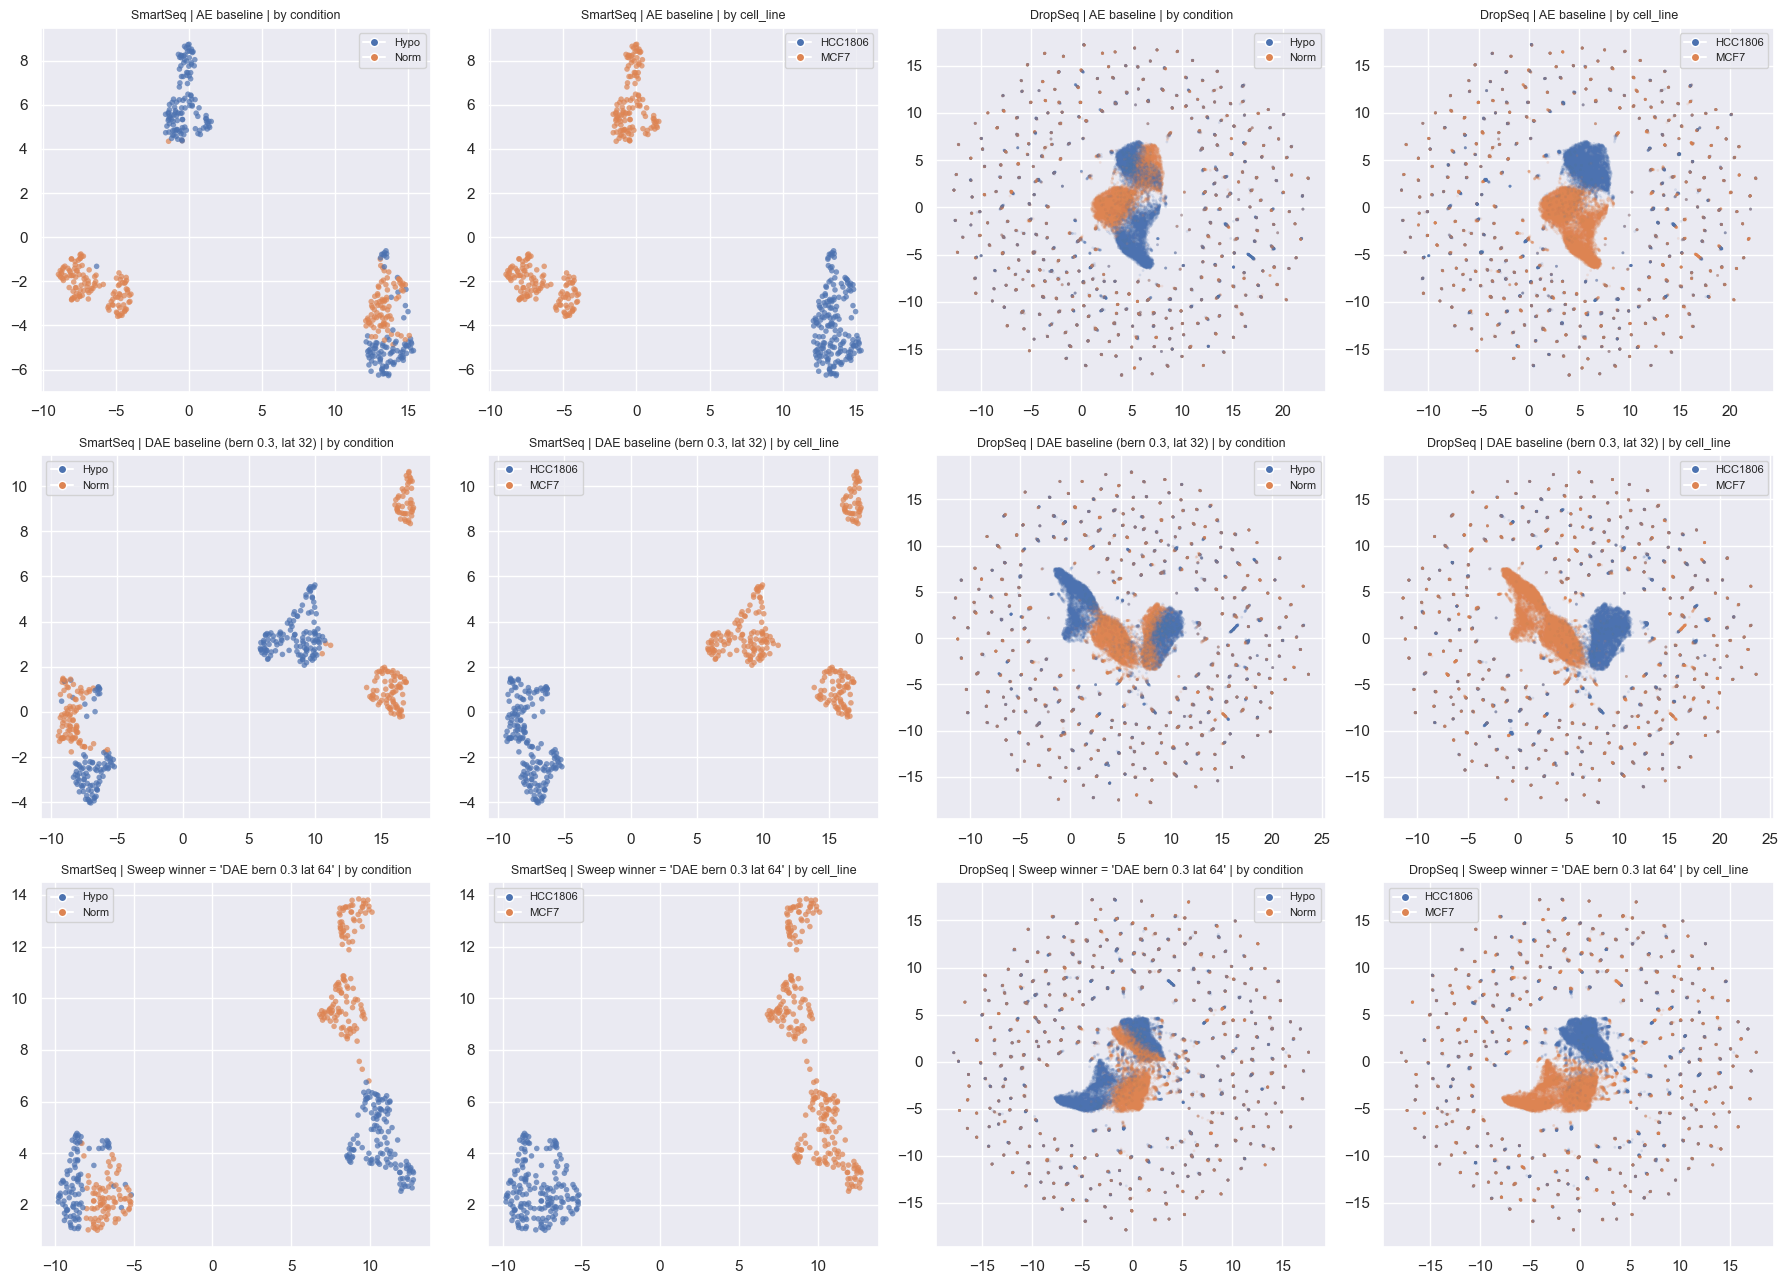

In [17]:
rows_spec = [
    ('AE baseline',  ae_models['SmartSeq']['Z'],   ae_models['DropSeq']['Z'],   None,                None),
    ('DAE baseline (bern 0.3, lat 32)',
                     dae_models['SmartSeq']['Z'],  dae_models['DropSeq']['Z'],  None,                None),
    ('Sweep winner', best_smart['Z'],              best_drop['Z'],              best_smart['name'],  best_drop['name']),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
for row, (label, Z_ss, Z_ds, ss_tag, ds_tag) in enumerate(rows_spec):
    for col_pair, (tech, Z, tag) in enumerate([
        ('SmartSeq', Z_ss, ss_tag),
        ('DropSeq',  Z_ds, ds_tag),
    ]):
        df_tech = ae_data[tech]['df_tech']
        s, alpha = (16, 0.7) if tech == 'SmartSeq' else (4, 0.15)
        reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.3)
        u = np.asarray(reducer.fit_transform(Z))
        title_label = f'{label} = {tag!r}' if tag else label
        for col_offset, colour_by in enumerate(['condition', 'cell_line']):
            ax = axes[row, col_pair * 2 + col_offset]
            _scatter_mixed(ax, u[:, 0], u[:, 1], df_tech[colour_by].values, s=s, alpha=alpha)
            ax.set_title(f'{tech} | {title_label} | by {colour_by}', fontsize=9)
plt.tight_layout(); plt.show()


## XGBoost

In [23]:
# --- XGBoost feature representations: raw genes / PCA / UMAP / AE latent ---
# Task: classify Hypoxia vs Normoxia from each technology. For every technology
# we build four feature *views* of the SAME cells (all in df_tech row order),
# then reuse the AE train/val split (ae_data[tech]['idx_tr' / 'idx_va']),
# restricted to cells with a known condition - this is exactly how sep_auc()
# scored the AE sweep, so the XGBoost numbers are directly comparable.
#
#   raw  : log1p gene-expression matrix       (df_tech[gene_cols], the un-reduced
#                                               features - no AE/PCA in between)
#   pca  : 10-component PCA embedding          (per_tech_pca[tech] -> emb_tech)
#   umap : 2-D UMAP embedding via _umap_on()   (PCA(30) -> UMAP, the notebook recipe)
#   ae   : trained-autoencoder latent Z        (the sweep winner per tech, best_*['Z']);
#                                               same latent sep_auc() scored with its
#                                               built-in LogisticRegression, now an
#                                               XGBoost input pipeline instead.
#
# PCA/UMAP reuse the notebook's existing unsupervised fits (fit on all cells),
# so these views are identical to the EDA figures earlier in the notebook.
# Trees are scale-invariant, so 'raw' is left un-standardised on purpose.

ae_winner = {'SmartSeq': best_smart, 'DropSeq': best_drop}   # sweep-winning AE per tech

xgb_reps = {}
for tech in ('SmartSeq', 'DropSeq'):
    df_tech, gene_cols, Xs_tech, _, emb_tech = per_tech_pca[tech]
    d = ae_data[tech]

    reps = {
        'raw':  df_tech[gene_cols].values.astype('float32'),   # (n_cells, n_genes)
        'pca':  np.asarray(emb_tech, dtype='float32'),         # (n_cells, 10)
        'umap': _umap_on(Xs_tech).astype('float32'),           # (n_cells, 2)
        'ae':   np.asarray(ae_winner[tech]['Z'], dtype='float32'),  # (n_cells, latent)
    }

    cond  = df_tech['condition'].values
    known = pd.notna(cond)
    y     = (cond == 'Hypo').astype(int)

    n = len(df_tech)
    m_tr = np.zeros(n, bool); m_tr[d['idx_tr']] = True; m_tr &= known
    m_va = np.zeros(n, bool); m_va[d['idx_va']] = True; m_va &= known

    xgb_reps[tech] = {'reps': reps, 'y': y, 'm_tr': m_tr, 'm_va': m_va}
    print(f"{tech:<8} | train={m_tr.sum():>5} val={m_va.sum():>5} labelled cells | "
          f"raw={reps['raw'].shape[1]}d  pca={reps['pca'].shape[1]}d  "
          f"umap={reps['umap'].shape[1]}d  ae={reps['ae'].shape[1]}d "
          f"({ae_winner[tech]['name']!r})")


SmartSeq | train=  345 val=   87 labelled cells | raw=1208d  pca=10d  umap=2d  ae=64d ('DAE bern 0.3 lat 64')
DropSeq  | train=29046 val= 7262 labelled cells | raw=834d  pca=10d  umap=2d  ae=64d ('DAE bern 0.3 lat 64')


In [24]:
# --- Generalised XGBoost trainer (built for hyperparameter tuning) ---
from xgboost import XGBClassifier

def train_xgboost(X_tr, y_tr, X_va, y_va, *,
                  n_estimators=400, max_depth=4, learning_rate=0.1,
                  subsample=0.9, colsample_bytree=0.9, min_child_weight=1.0,
                  reg_lambda=1.0, reg_alpha=0.0, early_stopping_rounds=30,
                  seed=SEED, **extra_params):
    """
    Train an XGBoost binary classifier (Hypo=1 / Norm=0) and record train & val
    accuracy and AUC at *every boosting round* - the 'training period' we plot.

    eval_metric=['error', 'auc']: XGBoost early-stops on the LAST metric of the
    LAST eval set, i.e. val AUC, and best_iteration is the round that maximised
    it. Accuracy is recovered as acc = 1 - error.

    All hyperparameters are keyword args (plus **extra_params) so this same
    function drives manual sweeps / GridSearch-style tuning - just vary the
    kwargs and read history['best_val_auc'] / history['best_val_acc'].

    Returns (model, history) where
      history = {
        'train': {'acc': [...per round...], 'auc': [...]},
        'val':   {'acc': [...],            'auc': [...]},
        'best_iteration': int,            # 0-based best round (val AUC)
        'best_val_acc':   float,          # accuracy at best_iteration
        'best_val_auc':   float,          # AUC at best_iteration
        'params':         {...},
      }
    """
    params = dict(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
        subsample=subsample, colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight, reg_lambda=reg_lambda, reg_alpha=reg_alpha,
        objective='binary:logistic', eval_metric=['error', 'auc'],
        early_stopping_rounds=early_stopping_rounds, tree_method='hist',
        n_jobs=-1, random_state=seed, **extra_params,
    )
    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=False)

    res = model.evals_result()
    tr, va = res['validation_0'], res['validation_1']
    history = {
        'train': {'acc': [1.0 - e for e in tr['error']], 'auc': list(tr['auc'])},
        'val':   {'acc': [1.0 - e for e in va['error']], 'auc': list(va['auc'])},
        'best_iteration': int(model.best_iteration),
        'params': params,
    }
    bi = history['best_iteration']
    history['best_val_acc'] = history['val']['acc'][bi]
    history['best_val_auc'] = history['val']['auc'][bi]
    return model, history


In [26]:
# --- Train XGBoost on every (technology x representation) with default params ---
xgb_models = {}
for tech in ('SmartSeq', 'DropSeq'):
    R = xgb_reps[tech]
    for rep_name, X in R['reps'].items():
        X_tr, y_tr = X[R['m_tr']], R['y'][R['m_tr']]
        X_va, y_va = X[R['m_va']], R['y'][R['m_va']]
        model, history = train_xgboost(X_tr, y_tr, X_va, y_va)
        xgb_models[(tech, rep_name)] = {'model': model, 'history': history}
        print(f"{tech:<8} {rep_name:<4} | best round {history['best_iteration'] + 1:>3} | "
              f"val acc {history['best_val_acc']:.3f} | val auc {history['best_val_auc']:.3f}")

xgb_summary = pd.DataFrame([
    {'tech': t, 'representation': r,
     'n_features': xgb_reps[t]['reps'][r].shape[1],
     'best_round': m['history']['best_iteration'] + 1,
     'val_acc':    m['history']['best_val_acc'],
     'val_auc':    m['history']['best_val_auc']}
    for (t, r), m in xgb_models.items()
]).sort_values(['tech', 'representation']).reset_index(drop=True)
xgb_summary


SmartSeq raw  | best round  53 | val acc 0.989 | val auc 0.997
SmartSeq pca  | best round  16 | val acc 0.989 | val auc 0.999
SmartSeq umap | best round  12 | val acc 0.931 | val auc 0.989
SmartSeq ae   | best round  68 | val acc 0.954 | val auc 0.990
DropSeq  raw  | best round 400 | val acc 0.937 | val auc 0.983
DropSeq  pca  | best round 397 | val acc 0.939 | val auc 0.987
DropSeq  umap | best round 251 | val acc 0.866 | val auc 0.944
DropSeq  ae   | best round 399 | val acc 0.895 | val auc 0.962


,tech,representation,n_features,best_round,val_acc,val_auc
0,DropSeq,ae,64,399,0.894657,0.962212
1,DropSeq,pca,10,397,0.938722,0.986720
2,DropSeq,raw,834,400,0.937345,0.983010
3,DropSeq,umap,2,251,0.866428,0.943900
4,SmartSeq,ae,64,68,0.954023,0.990476
5,SmartSeq,pca,10,16,0.988506,0.999471
6,SmartSeq,raw,1208,53,0.988506,0.997354
7,SmartSeq,umap,2,12,0.931034,0.989418


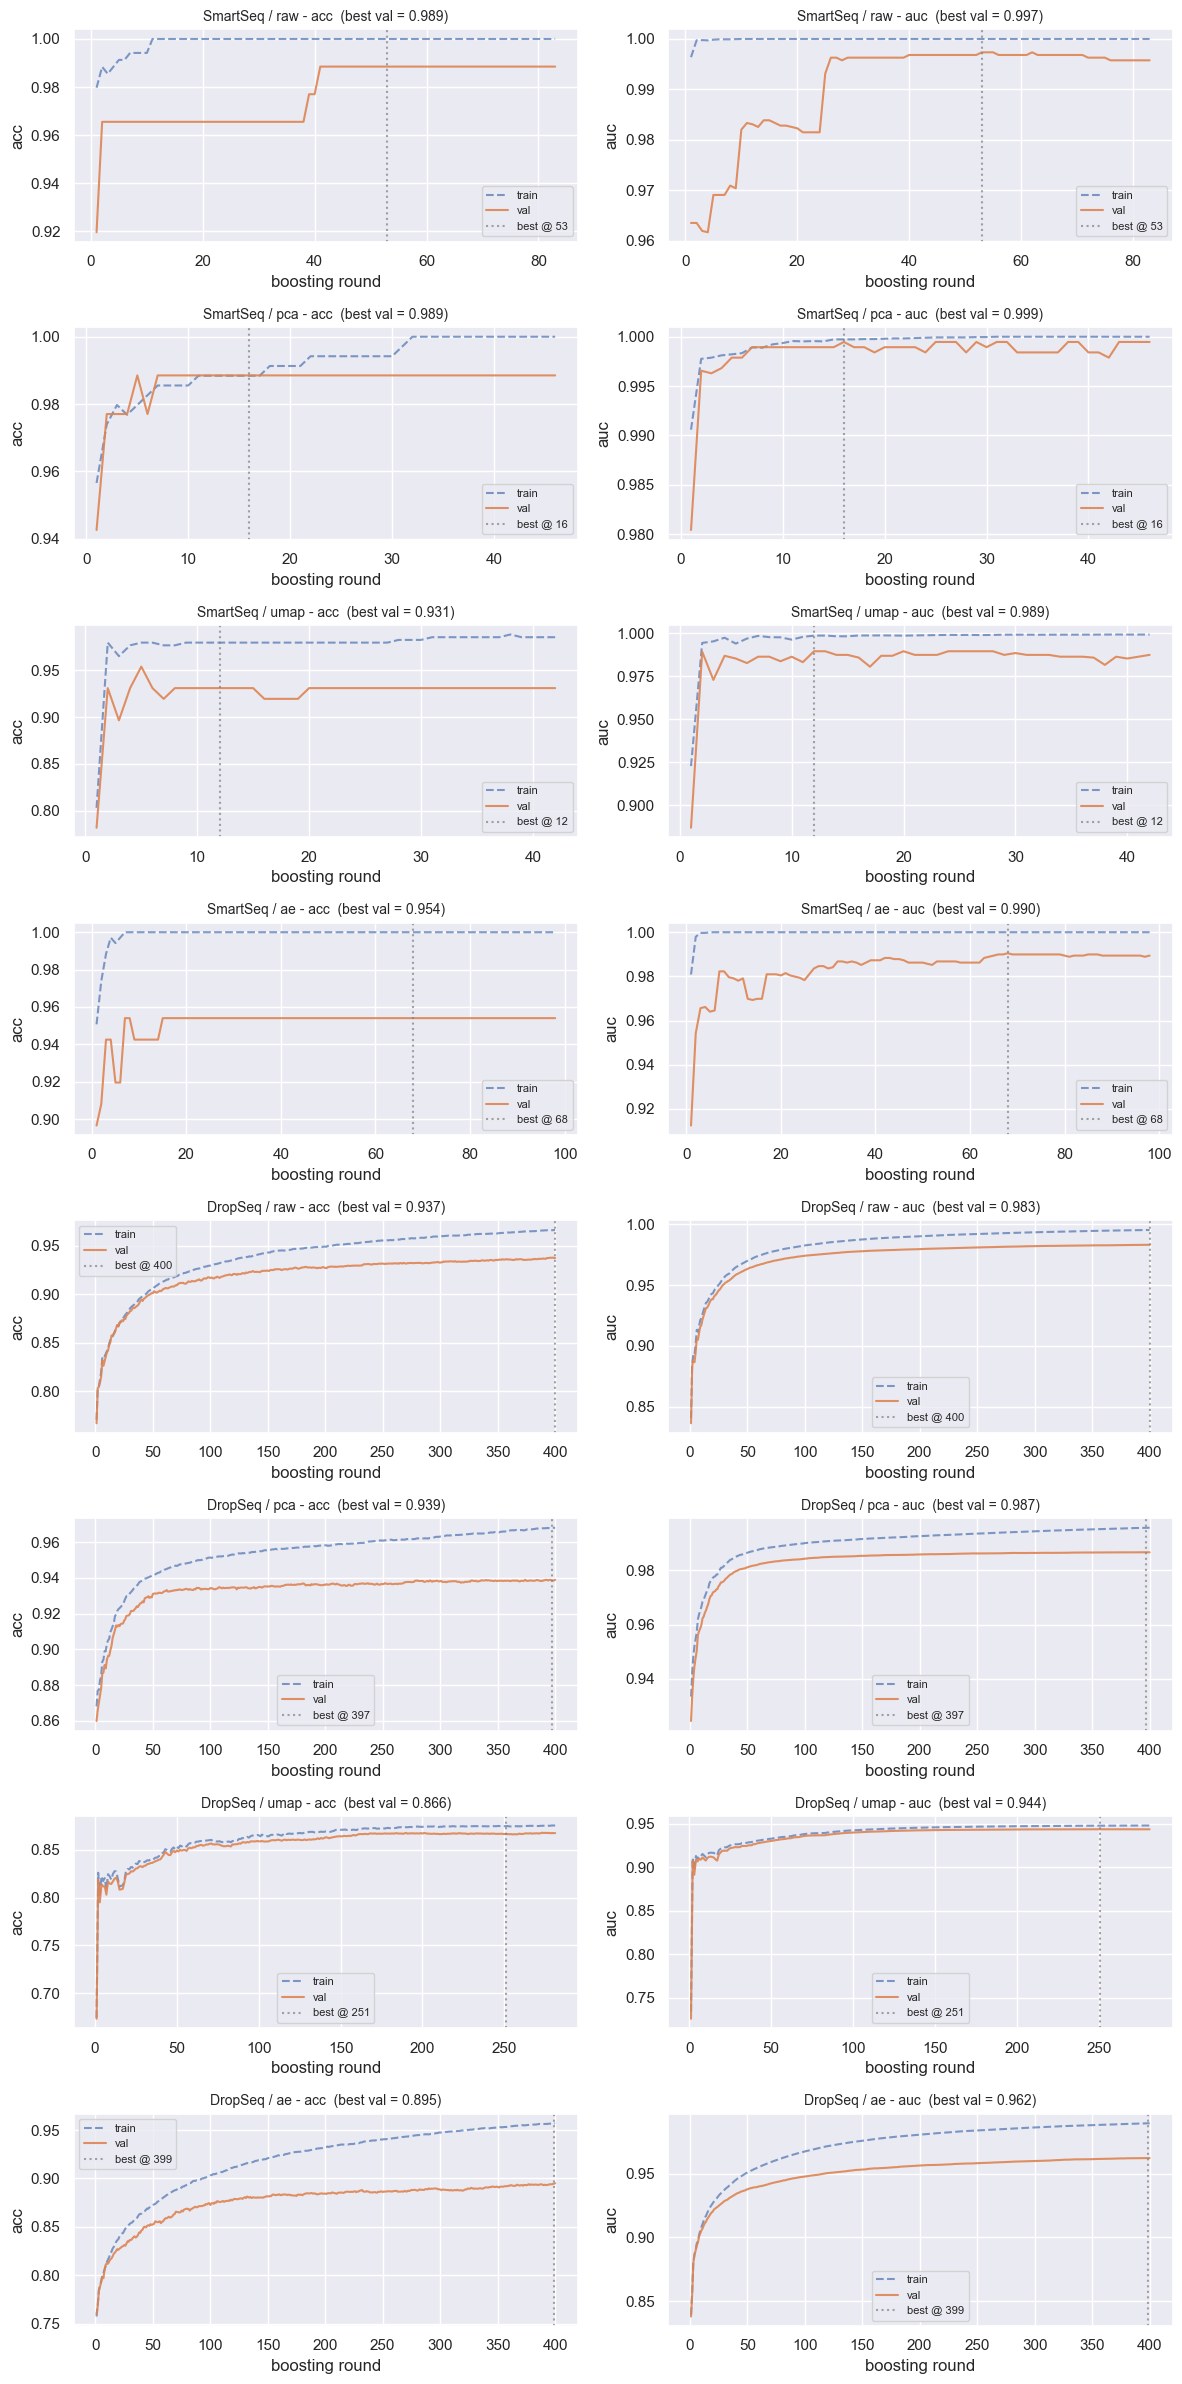

In [27]:
# --- Accuracy & AUC over the training period (boosting rounds) for each model ---
# One row per (technology, representation); left = accuracy, right = AUC.
# train (dashed) vs val (solid); the dotted line marks the early-stopping best
# round (chosen on val AUC). Val curves are the primary read.
combos = [(t, r) for t in ('SmartSeq', 'DropSeq') for r in ('raw', 'pca', 'umap', 'ae')]

fig, axes = plt.subplots(len(combos), 2, figsize=(12, 3.0 * len(combos)))
for row, (tech, rep) in enumerate(combos):
    h = xgb_models[(tech, rep)]['history']
    rounds = np.arange(1, len(h['val']['acc']) + 1)
    bi = h['best_iteration']
    for col, metric in enumerate(['acc', 'auc']):
        ax = axes[row, col]
        ax.plot(rounds, h['train'][metric], '--', alpha=0.7, label='train')
        ax.plot(rounds, h['val'][metric],   '-',  alpha=0.9, label='val')
        ax.axvline(bi + 1, color='grey', ls=':', alpha=0.7, label=f'best @ {bi + 1}')
        ax.set_title(f'{tech} / {rep} - {metric}  (best val = {h["val"][metric][bi]:.3f})',
                     fontsize=10)
        ax.set_xlabel('boosting round'); ax.set_ylabel(metric)
        ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
